# Математическая статистика

# Задание 2 Python
Дан файл со значениями характеристик ВУЗов РФ. Прочитать значения среднего балла ЕГЭ ege_budg и общего дохода ВУЗа total_income, очистить выборку от данных с ege_budg вне диапазона [50, 100].

Построить гистограммы среднего балла ЕГЭ и общего дохода ВУЗа для исходной и очищенной выборок.

Далее использовать только очищенную выборку.

Вычислить выборочное среднее и среднеквадратическое отклонение среднего балла ЕГЭ и общего дохода ВУЗа. Вычислить ковариацию и коэффициент корреляции по формуле и с помощью scipy.stats.


Сделать вывод о связи на основании значения ковариации и коэффициента корреляции.

Построить доверительные интервалы с доверительной вероятностью 95% и 98% для матожидания и дисперсии среднего балла ЕГЭ и общего дохода ВУЗа.

#Формулы для анализа

**Выборочное среднее**
$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$, $\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$

**Выборочная дисперсия**
$D_x = \frac{1}{n}\sum_{i=1}^{n} (x_i - \bar{x})^2$, $D_y = \frac{1}{n}\sum_{i=1}^{n} (y_i - \bar{y})^2$

**Ковариация**
$\text{cov}(x,y) = \frac{1}{n}\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$

**Коэффициент корреляции Пирсона**
$r = \frac{\text{cov}(x,y)}{\sqrt{D_x \cdot D_y}}$

**Критерий значимости**

Если $p\text{-значение} < 0.05$, то связь статистически значима.

#Интерпретация коэффициента корреляции
- $|r| \leq 0.3$ — слабая связь
- $0.3 < |r| \leq 0.7$ — умеренная связь
- $|r| > 0.7$ — сильная связь


Функции pandas
- pd.read\_excel() – чтение Excel файла
- df.shape – размерность DataFrame
- df.columns.tolist() – список столбцов
- df['column'].notna() – проверка на не-NaN значения
- df.copy() – копирование DataFrame
- df['col1'].cov(df['col2']) – ковариация
- df['col1'].corr(df['col2']) – коэффициент корреляции

Функции numpy
- np.mean() – среднее значение
- np.sum() – сумма элементов
- np.sqrt() – квадратный корень

Функции scipy.stats
- stats.pearsonr() – коэффициент корреляции Пирсона с p-значением

Функции matplotlib
- plt.subplots() – создание подграфиков
- ax.hist() – построение гистограммы
- ax.set\_xlabel(), ax.set\_ylabel() – подписи осей
- ax.set\_title() – заголовок графика
- ax.axvline() – вертикальная линия
- ax.legend() – легенда графика
- plt.tight\_layout() – автоматическая настройка расположения
- plt.savefig() – сохранение графика
- plt.show() – отображение графика

Методы DataFrame и встроенные функции
- all() – проверка всех элементов
- if col not in df.columns – проверка наличия столбца
- .format() и f-строки – форматирование вывода

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# Загружаем данные из файла
file_path = 'data.xlsx'
df = pd.read_excel(file_path, header=0)
df.head()

,federal_district,federal_district_short,region_code,region_name,okato,id,name,name_short,year,e1,...,square,phd_share,pps,rnd_private,pk,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,Южный федеральный округ,ЮФО,1,Республика Адыгея (Адыгея),79000000000,1,Федеральное государственное бюджетное образова...,ФГБОУ ВО «АГУ»,2013,61.88,...,53753.0,86.11,420.0,12016.20,3781.40,NaN,NaN,NaN,NaN,NaN
1,Южный федеральный округ,ЮФО,1,Республика Адыгея (Адыгея),79000000000,1,Федеральное государственное бюджетное образова...,ФГБОУ ВО «АГУ»,2014,55.81,...,53753.0,88.74,398.0,11741.00,3749.05,NaN,NaN,NaN,NaN,NaN
2,Южный федеральный округ,ЮФО,1,Республика Адыгея (Адыгея),79000000000,1,Федеральное государственное бюджетное образова...,ФГБОУ ВО «АГУ»,2015,57.45,...,51206.0,88.72,385.0,19762.05,3459.40,NaN,NaN,NaN,NaN,NaN
3,Южный федеральный округ,ЮФО,1,Республика Адыгея (Адыгея),79000000000,1,Федеральное государственное бюджетное образова...,ФГБОУ ВО «АГУ»,2016,59.44,...,60484.0,90.93,373.0,21984.62,3514.65,NaN,NaN,NaN,NaN,NaN
4,Южный федеральный округ,ЮФО,1,Республика Адыгея (Адыгея),79000000000,1,Федеральное государственное бюджетное образова...,ФГБОУ ВО «АГУ»,2017,60.15,...,60471.0,90.36,363.0,27054.39,4179.00,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Создаем новую таблицу
df_new = df[['ege_budg', 'total_income']].copy() # Копируем 2 солбца из df
# Оставлемя только те строки, в которых занчение столбца 'ege_budg' в диапазоне [50, 100]
df_new = df_new[(df_new['ege_budg'] >= 50) & (df_new['ege_budg'] <= 100)].copy().dropna()
df_new.head()

,ege_budg,total_income
0,63.03,1183805.084
1,57.60,1258764.500
2,58.58,1192261.000
3,60.76,760364.600
4,61.82,741335.000


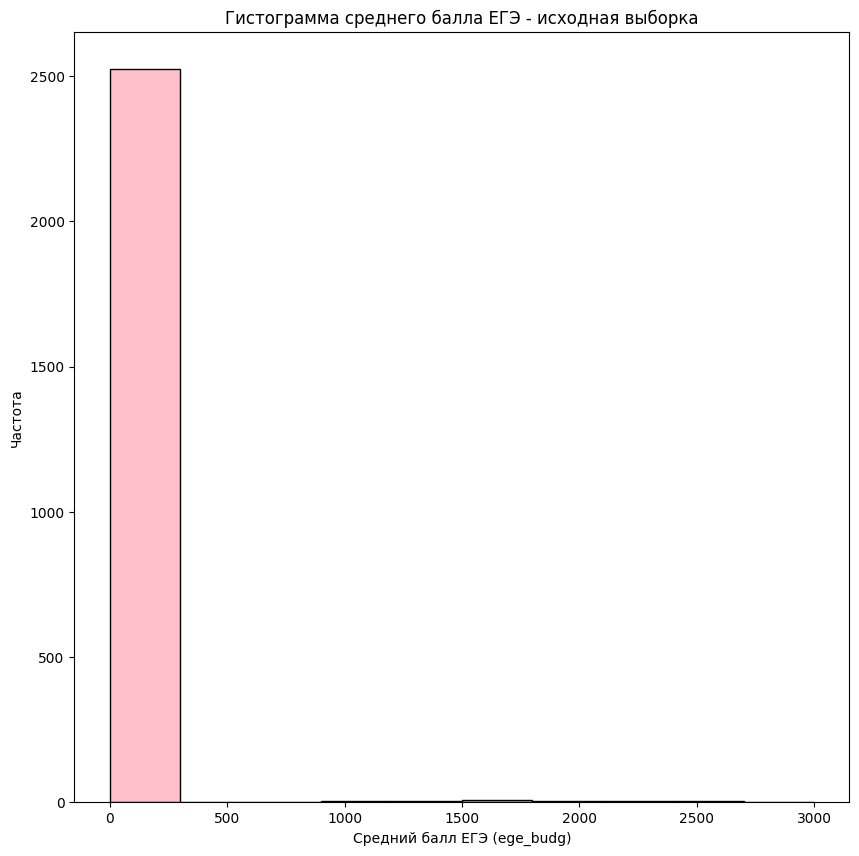

In [ ]:
# Строим гистограмму среднего балла ЕГЭ для исходных данных
plt.figure(figsize=(10, 10))
plt.hist(df['ege_budg'].dropna(), bins=10, color='pink', edgecolor='black')
plt.xlabel('Средний балл ЕГЭ (ege_budg)')
plt.ylabel('Частота')
plt.title('Гистограмма среднего балла ЕГЭ - исходная выборка')
plt.show()

При построении гистограммы среднего балла ЕГЭ для исходных данных была обнаружена аномалия: на графике присутствуют столбецы в диапазоне значений больше 100 баллов, что в реальности невозможно, поскольку максимально возможный балл ЕГЭ составляет 100 баллов.

In [ ]:
# Проверяем, есть ли значения больше 100
outliers = df['ege_budg'] > 100

# Количество выбросов
count_outliers = outliers.sum()

# Максимальный балл среди выбросов
max_outlier = df.loc[outliers, 'ege_budg'].max()

print(f"Количество значений > 100: {count_outliers}")
print(f"Максимальный балл среди них: {max_outlier}")

Количество значений > 100: 179
Максимальный балл среди них: 2999.2


Да, дейстивтельно в исходной выборки присутсвуют занчения среднего балла > 100.

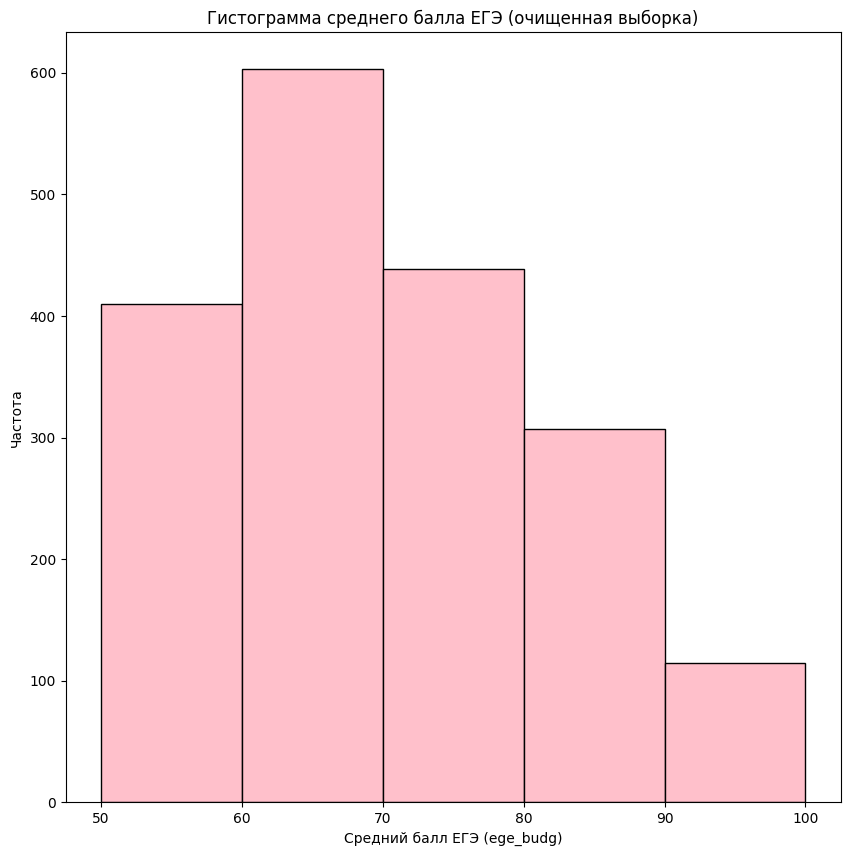

In [ ]:
# Строим гистограмму среднего балла ЕГЭ для очищенных данных
plt.figure(figsize=(10, 10))
plt.hist(df_new['ege_budg'], bins=5, color='pink', edgecolor='black')
plt.xlabel('Средний балл ЕГЭ (ege_budg)')
plt.ylabel('Частота')
plt.title('Гистограмма среднего балла ЕГЭ (очищенная выборка)')
plt.show()

Больше всего занчений попадает в интервал 60-70 баллов.

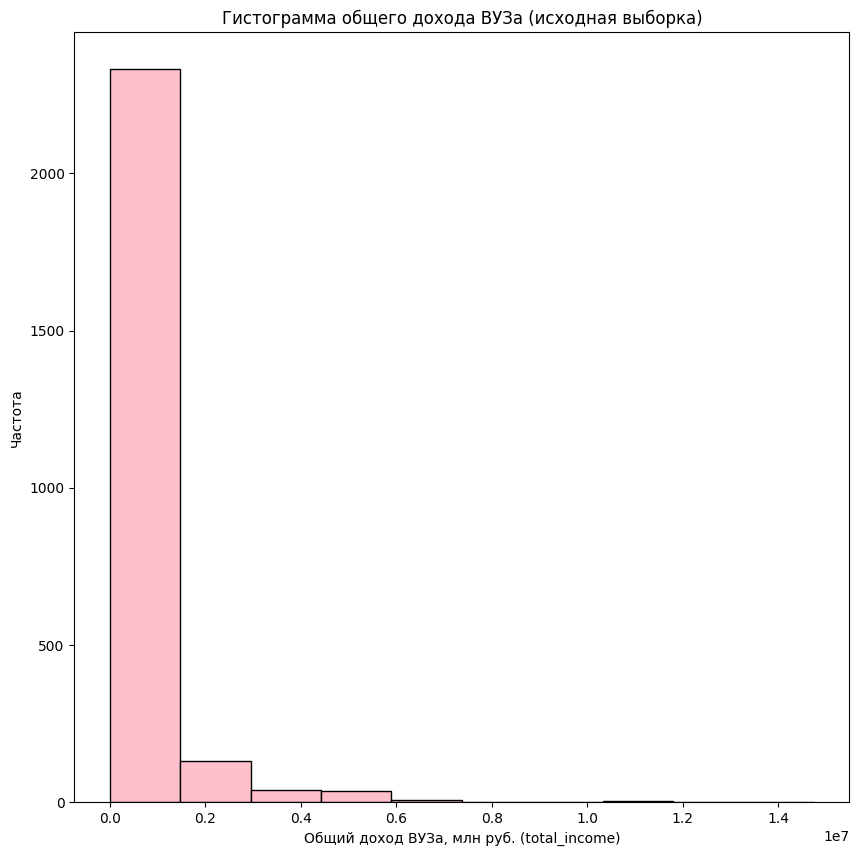

In [ ]:
# Строим гистограмму общего дохода ВУЗ для исходных данных
plt.figure(figsize=(10, 10))
plt.hist(df['total_income'].dropna(), color='pink', edgecolor='black')
plt.xlabel('Общий доход ВУЗа, млн руб. (total_income)')
plt.ylabel('Частота')
plt.title('Гистограмма общего дохода ВУЗа (исходная выборка)')
plt.show()

Гистограмма дохода ВУЗа демонстрирует сильную асимметрию: большинство вузов (основная масса) имеют доход до 0.2 млн рублей, при этом присутствуют единичные выбросы со значениями более 0.6–1.0 млн рублей.

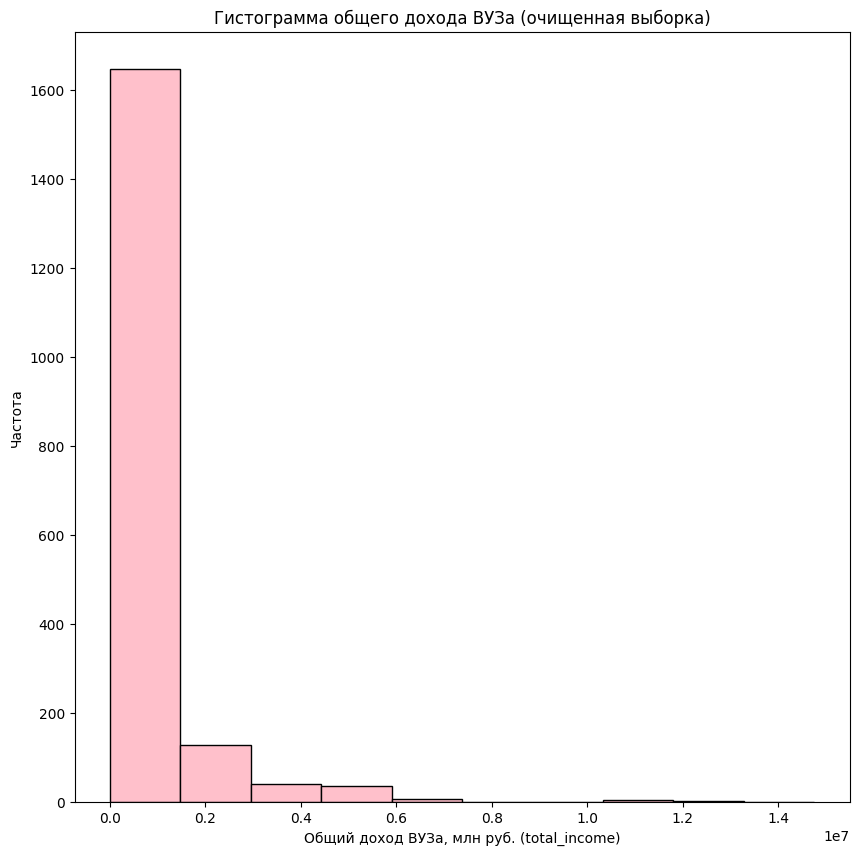

In [ ]:
# Строим гистограмму общего дохода ВУЗ для очищенных данных
plt.figure(figsize=(10, 10))
plt.hist(df_new['total_income'], color='pink', edgecolor='black')
plt.xlabel('Общий доход ВУЗа, млн руб. (total_income)')
plt.ylabel('Частота')
plt.title('Гистограмма общего дохода ВУЗа (очищенная выборка)')
plt.show()

Вывод по графику аналогичен предыдущему.

In [ ]:
x = df_new['ege_budg']
y = df_new['total_income']
n = len(x)

In [ ]:
# Считаем выборочное среднее по формуле
x_mean = np.sum(x) / n
y_mean = np.sum(y) / n

print(f"Средний балл ЕГЭ: {x_mean:.2f}")
print(f"Средний доход ВУЗа: {y_mean:.2f} тыс. руб.")

Средний балл ЕГЭ: 69.95
Средний доход ВУЗа: 810838.00 тыс. руб.


In [ ]:
# Считаем выборочную дисперсию по формуле
D_x = np.sum((x - x_mean) ** 2) / n
D_y = np.sum((y - y_mean) ** 2) / n

print(f"Выборочная дисперсия балла ЕГЭ: {D_x:.2f}")
print(f"Выборочная дисперсия дохода ВУЗа: {D_y:.2f} тыс. руб.")

Выборочная дисперсия балла ЕГЭ: 139.37
Выборочная дисперсия дохода ВУЗа: 1753775053952.59 тыс. руб.


In [ ]:
# Среднеквадратическое отклонение
std_x = np.sqrt(D_x)
std_y = np.sqrt(D_y)

print(f"Среднеквадратическое отклонение балла ЕГЭ: {std_x:.4f}")
print(f"Среднеквадратическое отклонение дохода ВУЗа: {std_y:.4f}")

Среднеквадратическое отклонение балла ЕГЭ: 11.8054
Среднеквадратическое отклонение дохода ВУЗа: 1324301.7232


In [ ]:
# Ковариация (по формуле)
cov_xy = np.sum((x - x_mean) * (y - y_mean)) / n

# Коэффициент корреляции Пирсона (по формуле)
r_formula = cov_xy / np.sqrt(D_x * D_y)

# Ковариация и корреляция через pandas
cov_pandas = x.cov(y)
corr_pandas = x.corr(y)

# Коэффициент корреляции через scipy.stats
r_scipy, p_value = stats.pearsonr(x, y)

print(f"Ковариация (по формуле): {cov_xy:.4f}")
print(f"Ковариация (pandas): {cov_pandas:.4f}")
print(f"Коэффициент корреляции (по формуле): {r_formula:.4f}")
print(f"Коэффициент корреляции (pandas): {corr_pandas:.4f}")
print(f"Коэффициент корреляции (scipy.stats): {r_scipy:.4f}")
print(f"p-значение: {p_value}")

Ковариация (по формуле): 2267646.3605
Ковариация (pandas): 2268857.0633
Коэффициент корреляции (по формуле): 0.1450
Коэффициент корреляции (pandas): 0.1450
Коэффициент корреляции (scipy.stats): 0.1450
p-значение: 2.822660230006133e-10


Между средним баллом ЕГЭ и доходом ВУЗа выявлена слабая положительная статистически значимая связь (r = 0.145 < 0.3, p-value < 0.05). Это указывает на закономерность: чем выше средний балл ЕГЭ у вуза, тем выше его общий доход, однако связь выражена неярко, и существуют многочисленные исключения.

In [ ]:
# Доверительный интервал для математического ожидания
# Используется t-распределение Стьюдента
def conf_interval_mean(data, confidence):
    n = len(data)
    mean = np.mean(data)
    s = np.std(data, ddof=1)
    t_val = stats.t.ppf((1 + confidence) / 2, df=n-1)
    margin = t_val * s / np.sqrt(n)
    return (mean - margin, mean + margin)

In [ ]:
# Доверительный интервал для дисперсии
# Используется распределение хи-квадрат
def conf_interval_var(data, confidence):
    n = len(data)
    var = np.var(data, ddof=1)
    chi2_low = stats.chi2.ppf((1 - confidence) / 2, df=n-1)
    chi2_high = stats.chi2.ppf((1 + confidence) / 2, df=n-1)
    return ((n-1) * var / chi2_high, (n-1) * var / chi2_low)

In [ ]:
ege = df_new['ege_budg'].values
income = df_new['total_income'].values

for conf in [0.95, 0.98]:
    print(f"\n--- Уровень доверия: {conf*100:.0f}% ---")

    # Баллы ЕГЭ
    ci_mean_ege = conf_interval_mean(ege, conf)
    ci_var_ege = conf_interval_var(ege, conf)

    print(f"\nСредний балл ЕГЭ:")
    print(f"  ДИ для мат.ожидания: [{ci_mean_ege[0]:.2f}; {ci_mean_ege[1]:.2f}]")
    print(f"  ДИ для дисперсии:     [{ci_var_ege[0]:.2f}; {ci_var_ege[1]:.2f}]")

    # Доход
    ci_mean_income = conf_interval_mean(income, conf)
    ci_var_income = conf_interval_var(income, conf)

    print(f"\nОбщий доход ВУЗа:")
    print(f"  ДИ для мат.ожидания: [{ci_mean_income[0]:.2f}; {ci_mean_income[1]:.2f}]")
    print(f"  ДИ для дисперсии:     [{ci_var_income[0]:.2f}; {ci_var_income[1]:.2f}]")


--- Уровень доверия: 95% ---

Средний балл ЕГЭ:
  ДИ для мат.ожидания: [69.41; 70.48]
  ДИ для дисперсии:     [130.93; 148.82]

Общий доход ВУЗа:
  ДИ для мат.ожидания: [750824.79; 870851.22]
  ДИ для дисперсии:     [1647536479997.68; 1872748941643.87]

--- Уровень доверия: 98% ---

Средний балл ЕГЭ:
  ДИ для мат.ожидания: [69.31; 70.58]
  ДИ для дисперсии:     [129.40; 150.66]

Общий доход ВУЗа:
  ДИ для мат.ожидания: [739591.34; 882084.67]
  ДИ для дисперсии:     [1628373438081.31; 1895847757927.96]
